In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df=pd.read_csv("C:/Users/HP/Documents/My work/Quantium/Chip_sales2.csv")
df["Transaction_date"]=pd.to_datetime(df["Transaction_date"])
df["YearMonth"]=df["Transaction_date"].dt.strftime("%Y-%m")

In [5]:
Monthly_metrics=df.groupby(["Store_nbr","YearMonth"],observed=True).agg({
    "Total_sales":"sum",
    "loyalty_card_number":"nunique",
    "TXN":"nunique"
}).reset_index().rename(columns={
    "loyalty_card_number":"Total_customers",
    "TXN":"Total_Transactions"
})
print(Monthly_metrics)                                                                     

      Store_nbr YearMonth  Total_sales  Total_customers  Total_Transactions
0             1   2018-07        188.9               47                  49
1             1   2018-08        168.4               41                  41
2             1   2018-09        268.1               57                  59
3             1   2018-10        175.4               39                  40
4             1   2018-11        184.8               44                  45
...         ...       ...          ...              ...                 ...
3160        272   2019-02        385.3               44                  47
3161        272   2019-03        421.9               48                  51
3162        272   2019-04        445.1               54                  55
3163        272   2019-05        314.6               34                  40
3164        272   2019-06        301.9               33                  36

[3165 rows x 5 columns]


In [6]:
#Identify store 77 first
store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]

#List of stores
unique_stores=Monthly_metrics["Store_nbr"].unique()

#Putting the reslts inside thhesame cell
result=[]

#Loop through each store
for unique_store in unique_stores:
    if unique_store==77:
        continue
    other_store=Monthly_metrics[Monthly_metrics["Store_nbr"]==unique_store]
    
#Merge store 77 with other  store on Yearmonth(inner join by default)    
    comparison=pd.merge(
        store_77,
        other_store,
        on=["YearMonth"],
        suffixes=("_77","_other")
    )

#checking for full month coverge and required a non zero variation
    if len(comparison)==12:
        if (comparison["Total_sales_other"].std() > 0 and 
           comparison["Total_customers_other"].std() > 0 and
           comparison["Total_Transactions_other"].std() > 0):
            
            Sales_correlation=comparison["Total_sales_77"].corr(comparison["Total_sales_other"])
            Customer_correlation=comparison["Total_customers_77"].corr(comparison["Total_customers_other"])
            Transaction_correlation=comparison["Total_Transactions_77"].corr(comparison["Total_Transactions_other"])
            
            composite_score=( Sales_correlation+Customer_correlation+Transaction_correlation) / 3
            
            result.append({
                "unique_store":unique_store,
                "Sales_correlation":Sales_correlation,
                "Customer_correlation":Customer_correlation,
                "Transaction_correlation":Transaction_correlation,
                "composite_score":composite_score
            })
#Coverting into a dataframe and sort by highest correlation
results_df=pd.DataFrame(result)
results_df=results_df.sort_values(by="composite_score",ascending=False).reset_index(drop=True)
print(results_df.head(5))

   unique_store  Sales_correlation  Customer_correlation  \
0            35           0.782175              0.821569   
1           167           0.698594              0.767897   
2           157           0.677769              0.694382   
3           234           0.643556              0.593505   
4            53           0.666037              0.642504   

   Transaction_correlation  composite_score  
0                 0.735791         0.779845  
1                 0.769020         0.745171  
2                 0.703157         0.691770  
3                 0.670909         0.635990  
4                 0.586065         0.631535  


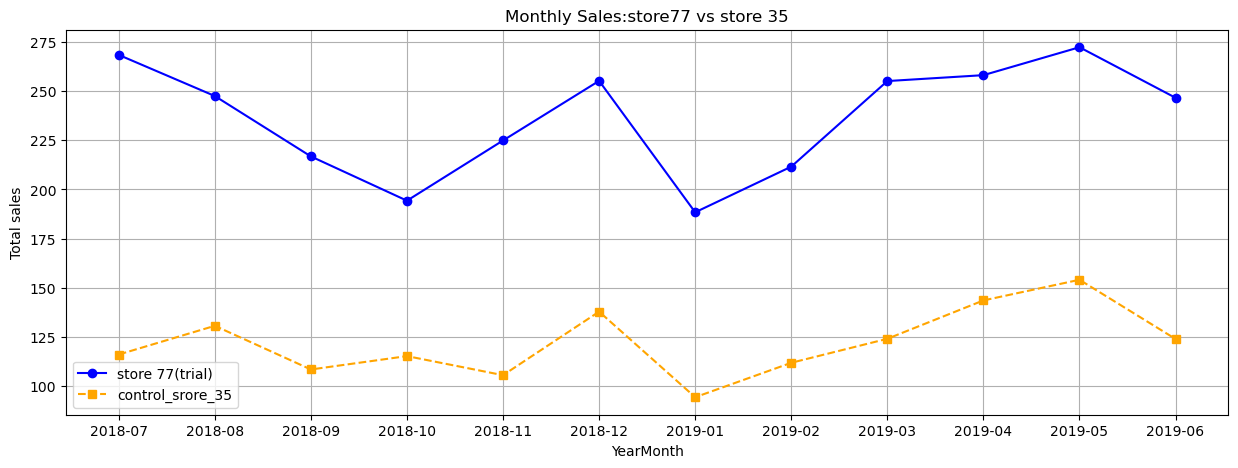

In [12]:
store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]
control_srore=Monthly_metrics[Monthly_metrics["Store_nbr"]==35]

#Setting the width and the height
plt.figure(figsize=(15,5))

#plot of store 77(line1)
plt.plot(
    store_77["YearMonth"],
    store_77["Total_sales"],
    label="store 77(trial)",
    marker="o",
    color="blue"
)
##plot other store(line 2)
plt.plot(
    control_srore["YearMonth"],
    control_srore["Total_sales"],
    label="control_srore_35",
    marker="s",
    color="orange",
    linestyle="--"
)
#Add label 
plt.xlabel("YearMonth")
plt.ylabel("Total sales")
plt.title("Monthly Sales:store77 vs store 35")
plt.legend()
plt.grid(True)

plt.show()


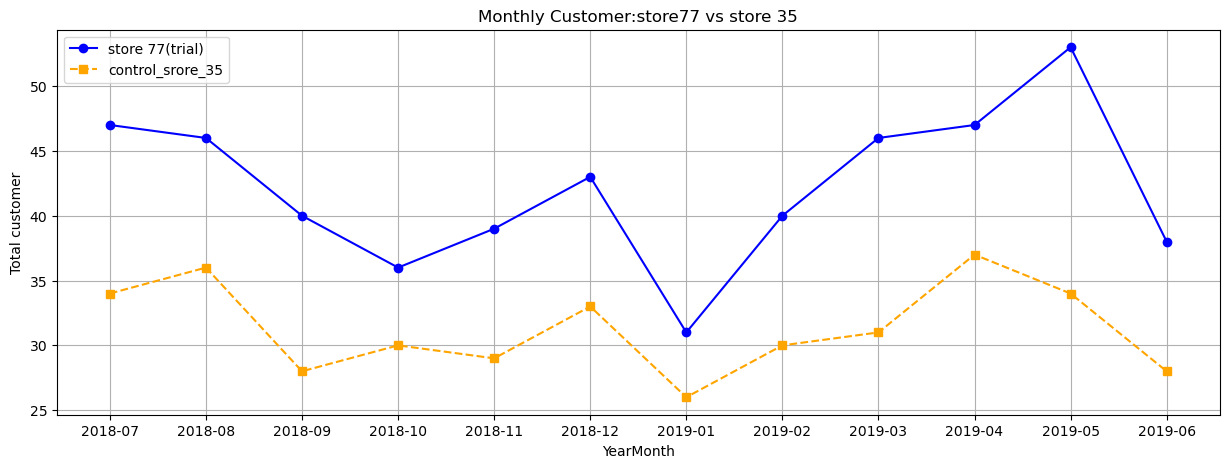

In [14]:
store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]
control_srore=Monthly_metrics[Monthly_metrics["Store_nbr"]==35]

#Setting the width and the height
plt.figure(figsize=(15,5))

#plot of store 77(line1)
plt.plot(
    store_77["YearMonth"],
    store_77["Total_customers"],
    label="store 77(trial)",
    marker="o",
    color="blue"
)
##plot other store(line 2)
plt.plot(
    control_srore["YearMonth"],
    control_srore["Total_customers"],
    label="control_srore_35",
    marker="s",
    color="orange",
    linestyle="--"
)
#Add label 
plt.xlabel("YearMonth")
plt.ylabel("Total customer")
plt.title("Monthly Customer:store77 vs store 35")
plt.legend()
plt.grid(True)

plt.show()


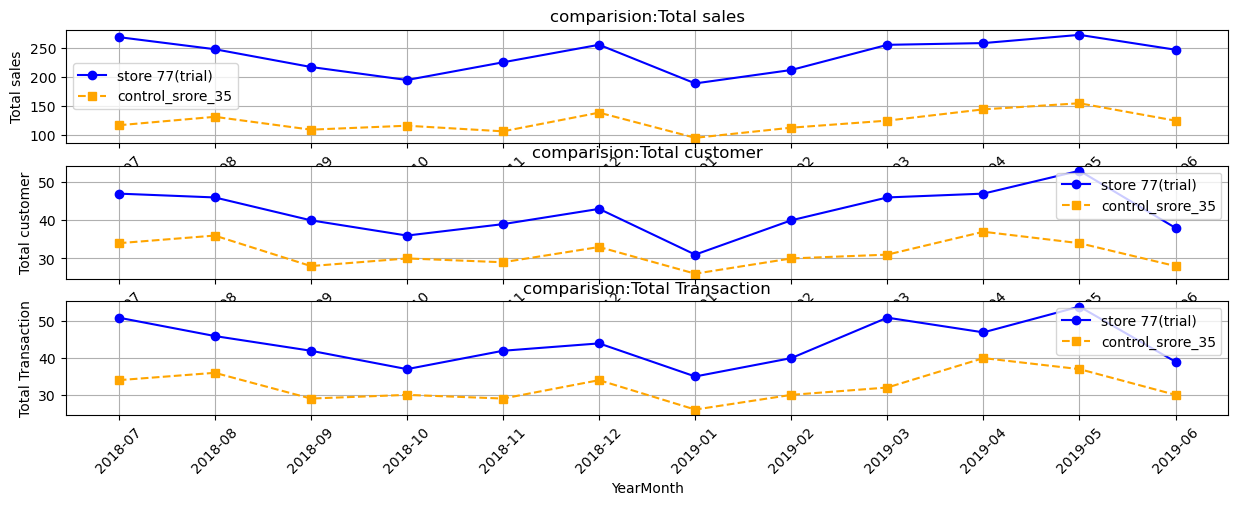

In [8]:
store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]
control_srore=Monthly_metrics[Monthly_metrics["Store_nbr"]==35]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(store_77["YearMonth"], store_77["Total_sales"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_sales"],label="control_srore_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(store_77["YearMonth"], store_77["Total_customers"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_customers"],label="control_srore_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(store_77["YearMonth"], store_77["Total_Transactions"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_Transactions"],label="control_srore_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)


plt.show()


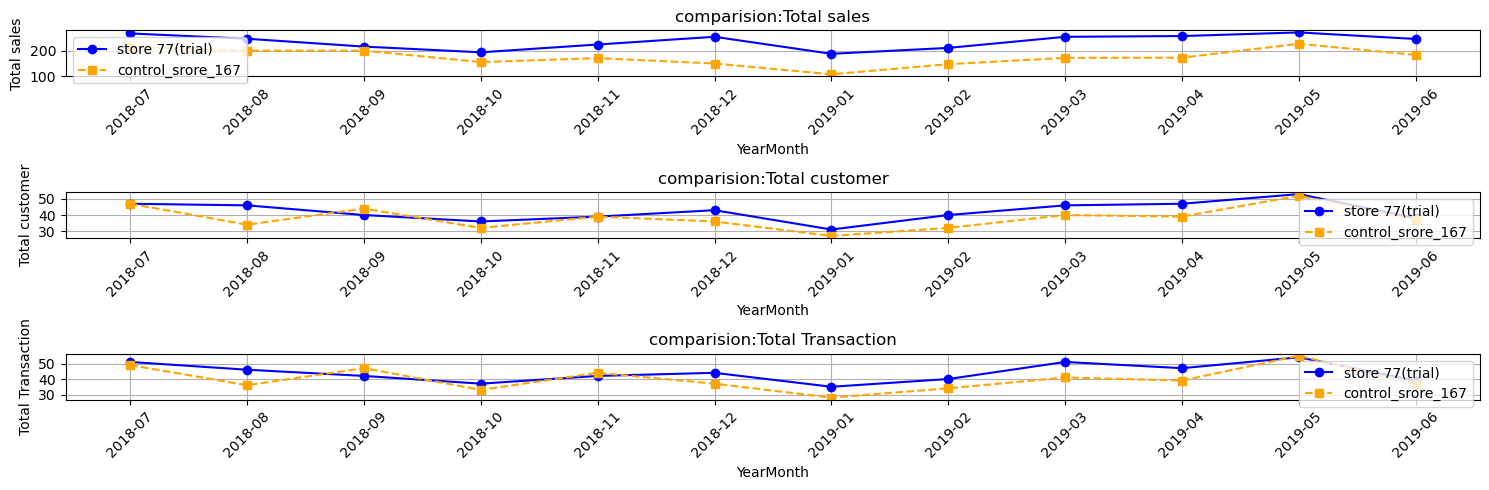

In [11]:
store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]
control_srore2=Monthly_metrics[Monthly_metrics["Store_nbr"]==167]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(store_77["YearMonth"], store_77["Total_sales"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore2["YearMonth"],control_srore2["Total_sales"],label="control_srore_167",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(store_77["YearMonth"], store_77["Total_customers"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore2["YearMonth"],control_srore2["Total_customers"],label="control_srore_167",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(store_77["YearMonth"], store_77["Total_Transactions"],label="store 77(trial)",marker="o",color="blue")
plt.plot(control_srore2["YearMonth"],control_srore2["Total_Transactions"],label="control_srore_167",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [16]:
#Identify store 86 first
store_86=Monthly_metrics[Monthly_metrics["Store_nbr"]==86]

#List of stores
unique_stores=Monthly_metrics["Store_nbr"].unique()

#Putting the reslts inside thhesame cell
result=[]

#Loop through each store
for unique_store in unique_stores:
    if unique_store==86:
        continue
    other_store=Monthly_metrics[Monthly_metrics["Store_nbr"]==unique_store]
    
#Merge store 86 with other  store on Yearmonth(inner join by default)    
    comparison=pd.merge(
        store_86,
        other_store,
        on=["YearMonth"],
        suffixes=("_86","_other")
    )

#checking for full month coverge and required a non zero variation
    if len(comparison)==12:
        if (comparison["Total_sales_other"].std() > 0 and 
           comparison["Total_customers_other"].std() > 0 and
           comparison["Total_Transactions_other"].std() > 0):
            
            Sales_correlation=comparison["Total_sales_86"].corr(comparison["Total_sales_other"])
            Customer_correlation=comparison["Total_customers_86"].corr(comparison["Total_customers_other"])
            Transaction_correlation=comparison["Total_Transactions_86"].corr(comparison["Total_Transactions_other"])
            
            composite_score=( Sales_correlation+Customer_correlation+Transaction_correlation) / 3
            
            result.append({
                "unique_store":unique_store,
                "Sales_correlation":Sales_correlation,
                "Customer_correlation":Customer_correlation,
                "Transaction_correlation":Transaction_correlation,
                "composite_score":composite_score
            })
#Coverting into a dataframe and sort by highest correlation
results_df=pd.DataFrame(result)
results_df=results_df.sort_values(by="composite_score",ascending=False).reset_index(drop=True)
print(results_df.head(5))

   unique_store  Sales_correlation  Customer_correlation  \
0           231           0.798316              0.456853   
1           147           0.542233              0.548903   
2           260           0.651642              0.587839   
3            25           0.698864              0.633757   
4           229           0.597385              0.701043   

   Transaction_correlation  composite_score  
0                 0.628722         0.627964  
1                 0.771852         0.620996  
2                 0.554902         0.598128  
3                 0.456664         0.596428  
4                 0.455630         0.584686  


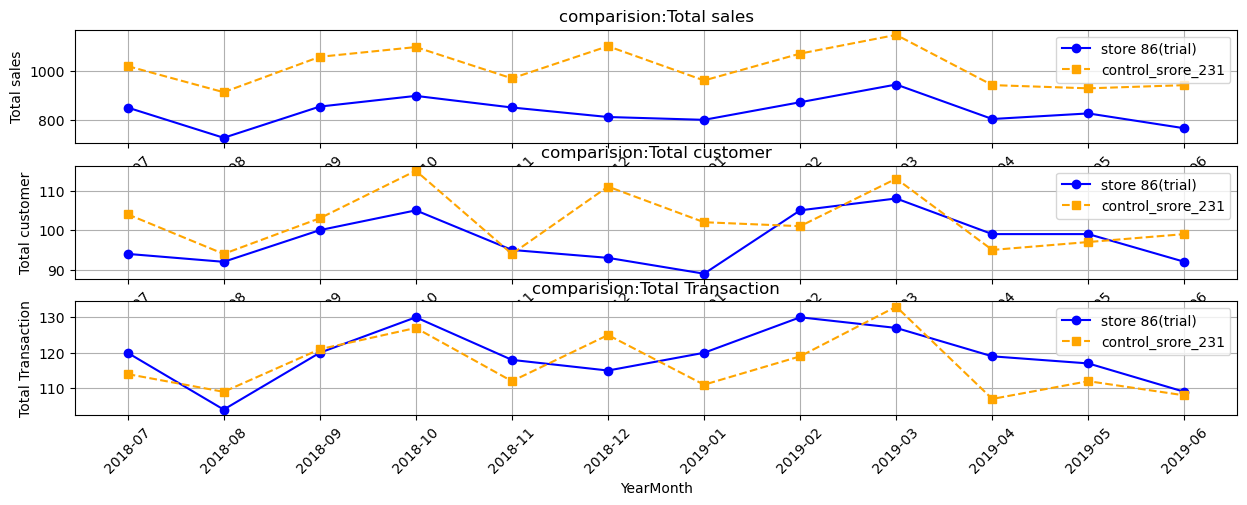

In [9]:
store_86=Monthly_metrics[Monthly_metrics["Store_nbr"]==86]
control_srore=Monthly_metrics[Monthly_metrics["Store_nbr"]==231]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(store_86["YearMonth"], store_86["Total_sales"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_sales"],label="control_srore_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(store_86["YearMonth"], store_86["Total_customers"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_customers"],label="control_srore_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(store_86["YearMonth"], store_86["Total_Transactions"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_srore["YearMonth"],control_srore["Total_Transactions"],label="control_srore_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)


plt.show()

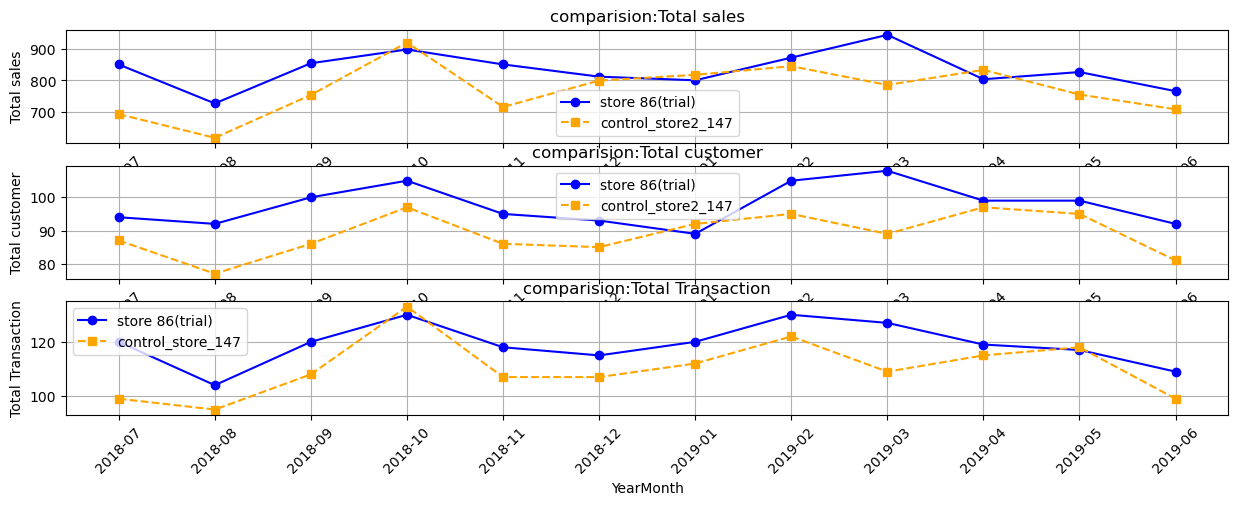

In [10]:
store_86=Monthly_metrics[Monthly_metrics["Store_nbr"]==86]
control_store2=Monthly_metrics[Monthly_metrics["Store_nbr"]==147]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(store_86["YearMonth"], store_86["Total_sales"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_store2["YearMonth"],control_store2["Total_sales"],label="control_store2_147",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(store_86["YearMonth"], store_86["Total_customers"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_store2["YearMonth"],control_store2["Total_customers"],label="control_store2_147",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(store_86["YearMonth"], store_86["Total_Transactions"],label="store 86(trial)",marker="o",color="blue")
plt.plot(control_store2["YearMonth"],control_store2["Total_Transactions"],label="control_store_147",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)


plt.show()

In [19]:
#Identify store 88 first
store_88=Monthly_metrics[Monthly_metrics["Store_nbr"]==88]

#List of stores
unique_stores=Monthly_metrics["Store_nbr"].unique()

#Putting the reslts inside thhesame cell
result=[]

#Loop through each store
for unique_store in unique_stores:
    if unique_store==88:
        continue
    other_store=Monthly_metrics[Monthly_metrics["Store_nbr"]==unique_store]
    
#Merge store 88 with other  store on Yearmonth(inner join by default)    
    comparison=pd.merge(
        store_88,
        other_store,
        on=["YearMonth"],
        suffixes=("_88","_other")
    )

#checking for full month coverge and required a non zero variation
    if len(comparison)==12:
        if (comparison["Total_sales_other"].std() > 0 and 
           comparison["Total_customers_other"].std() > 0 and
           comparison["Total_Transactions_other"].std() > 0):
            
            Sales_correlation=comparison["Total_sales_88"].corr(comparison["Total_sales_other"])
            Customer_correlation=comparison["Total_customers_88"].corr(comparison["Total_customers_other"])
            Transaction_correlation=comparison["Total_Transactions_88"].corr(comparison["Total_Transactions_other"])
            
            composite_score=( Sales_correlation+Customer_correlation+Transaction_correlation) / 3
            
            result.append({
                "unique_store":unique_store,
                "Sales_correlation":Sales_correlation,
                "Customer_correlation":Customer_correlation,
                "Transaction_correlation":Transaction_correlation,
                "composite_score":composite_score
            })
#Coverting into a dataframe and sort by highest correlation
results_df=pd.DataFrame(result)
results_df=results_df.sort_values(by="composite_score",ascending=False).reset_index(drop=True)
print(results_df.head(5))

   unique_store  Sales_correlation  Customer_correlation  \
0           229           0.662337              0.681161   
1           190           0.473678              0.672468   
2           159           0.839356              0.375970   
3           179           0.508423              0.517683   
4           188           0.593834              0.546007   

   Transaction_correlation  composite_score  
0                 0.721200         0.688232  
1                 0.651131         0.599093  
2                 0.542796         0.586041  
3                 0.695229         0.573778  
4                 0.572083         0.570641  


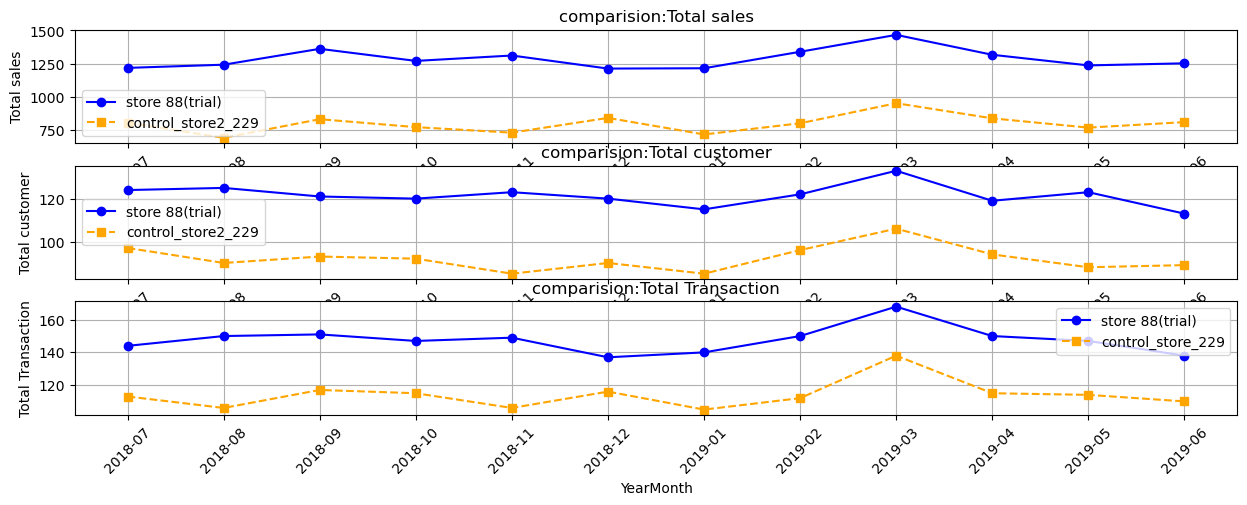

In [60]:
store_88=Monthly_metrics[Monthly_metrics["Store_nbr"]==88]
control_store=Monthly_metrics[Monthly_metrics["Store_nbr"]==229]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(store_88["YearMonth"], store_88["Total_sales"],label="store 88(trial)",marker="o",color="blue")
plt.plot(control_store["YearMonth"],control_store["Total_sales"],label="control_store2_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(store_88["YearMonth"], store_88["Total_customers"],label="store 88(trial)",marker="o",color="blue")
plt.plot(control_store["YearMonth"],control_store["Total_customers"],label="control_store2_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(store_88["YearMonth"], store_88["Total_Transactions"],label="store 88(trial)",marker="o",color="blue")
plt.plot(control_store["YearMonth"],control_store["Total_Transactions"],label="control_store_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)


plt.show()

In [14]:
df2=pd.read_csv("C:/Users/HP/Downloads/QVI_data.csv")
df2["DATE"]=pd.to_datetime(df2["DATE"])
df2["YearMonth"]=df2["DATE"].dt.strftime("%Y-%m")

In [35]:
df2.columns


Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER', 'YearMonth'],
      dtype='object')

In [15]:
Monthly_metrics_for_Trial_stores=df2.groupby(["STORE_NBR","YearMonth"]).agg({
    "TOT_SALES":"sum",
    "LYLTY_CARD_NBR":"nunique",
    "TXN_ID":"nunique"
}).reset_index().rename(columns={"TOT_SALES":"Total_sales","LYLTY_CARD_NBR":"Total_customer","TXN_ID":"Total_Transaction"})
print(Monthly_metrics_for_Trial_stores)     

      STORE_NBR YearMonth  Total_sales  Total_customer  Total_Transaction
0             1   2018-07        206.9              49                 52
1             1   2018-08        176.1              42                 43
2             1   2018-09        278.8              59                 62
3             1   2018-10        188.1              44                 45
4             1   2018-11        192.6              46                 47
...         ...       ...          ...             ...                ...
3164        272   2019-02        395.5              45                 48
3165        272   2019-03        442.3              50                 53
3166        272   2019-04        445.1              54                 55
3167        272   2019-05        314.6              34                 40
3168        272   2019-06        312.1              34                 37

[3169 rows x 5 columns]


In [16]:
store_77=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==77]
store_35=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==35]


In [17]:
#Percentage increase in the total sales comparing the Trial sales with the control store

#calculating the pretrial and Trial period for both trial and control store
PreTrial_store_77=(store_77["YearMonth"]>="2018-07")&(store_77["YearMonth"]<="2019-01")
Trial_store_77=(store_77["YearMonth"]>="2019-02")&(store_77["YearMonth"]<="2019-04")

PreTrial_store_35=(store_35["YearMonth"]>="2018-07")&(store_35["YearMonth"]<="2019-01")
Trial_store_35=(store_35["YearMonth"]>="2019-02")&(store_35["YearMonth"]<="2019-04")

#calculating total sales for pretrial and trial period for both Trial and control store
PreTrial_store_77_Totalsales=store_77.loc[PreTrial_store_77,"Total_sales"].sum()
PreTrial_store_35_Totalsales=store_35.loc[PreTrial_store_35,"Total_sales"].sum()
scaling_factor=PreTrial_store_77_Totalsales/PreTrial_store_35_Totalsales

Trial_store_77_Totalsales=store_77.loc[Trial_store_77,"Total_sales"].sum()
Trial_store_35_Totalsales=store_35.loc[Trial_store_35,"Total_sales"].sum()

#finding the scaling factor of the trial and the control store as they don't necessary have thesame output
scaled_trial_35=Trial_store_35_Totalsales*scaling_factor
percentage_lift=((Trial_store_77_Totalsales-scaled_trial_35)/scaled_trial_35)*100

print(f"percentage_change_Totalsales:{percentage_lift:.2f}%")

#Percentage increase in the total customers comparing the Trial sales with the control store
PreTrial_store_77_Customer=store_77.loc[PreTrial_store_77,"Total_customer"].sum()
PreTrial_store_35_Customer=store_35.loc[PreTrial_store_35,"Total_customer"].sum()
scaling_factor=PreTrial_store_77_Customer/PreTrial_store_35_Customer

Trial_store_77_Customer=store_77.loc[Trial_store_77,"Total_customer"].sum()
Trial_store_35_Customer=store_35.loc[Trial_store_35,"Total_customer"].sum()

scaled_trial_35=Trial_store_35_Customer*scaling_factor
percentage_lift=((Trial_store_77_Customer-scaled_trial_35)/scaled_trial_35)*100

print(f"percentage_change_customer:{percentage_lift:.2f}%")

#percentage incraese in the total transaction comparing the Trial sales with the control store
PreTrial_store_77_Transaction=store_77.loc[PreTrial_store_77,"Total_Transaction"].sum()
PreTrial_store_35_Transaction=store_35.loc[PreTrial_store_35,"Total_Transaction"].sum()
scaling_factor=PreTrial_store_77_Transaction/PreTrial_store_35_Transaction

Trial_store_77_Transaction=store_77.loc[Trial_store_77,"Total_Transaction"].sum()
Trial_store_35_Transaction=store_35.loc[Trial_store_35,"Total_Transaction"].sum()

scaled_trial_35=Trial_store_35_Transaction*scaling_factor
percentage_lift=((Trial_store_77_Transaction-scaled_trial_35)/scaled_trial_35)*100

print(f"percentage_change_TotalTransaction:{percentage_lift:.2f}%")

percentage_change_Totalsales:-2.55%
percentage_change_customer:4.75%
percentage_change_TotalTransaction:1.27%


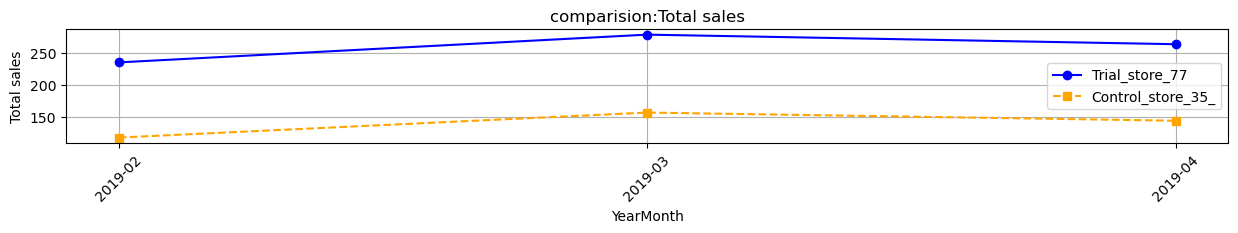

In [21]:
Trial_store_77_df=store_77[Trial_store_77]
Control_store_35_df=store_35[Trial_store_35]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(Trial_store_77_df["YearMonth"], Trial_store_77_df["Total_sales"],label="Trial_store_77",marker="o",color="blue")
plt.plot(Control_store_35_df["YearMonth"],Control_store_35_df["Total_sales"],label="Control_store_35_",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

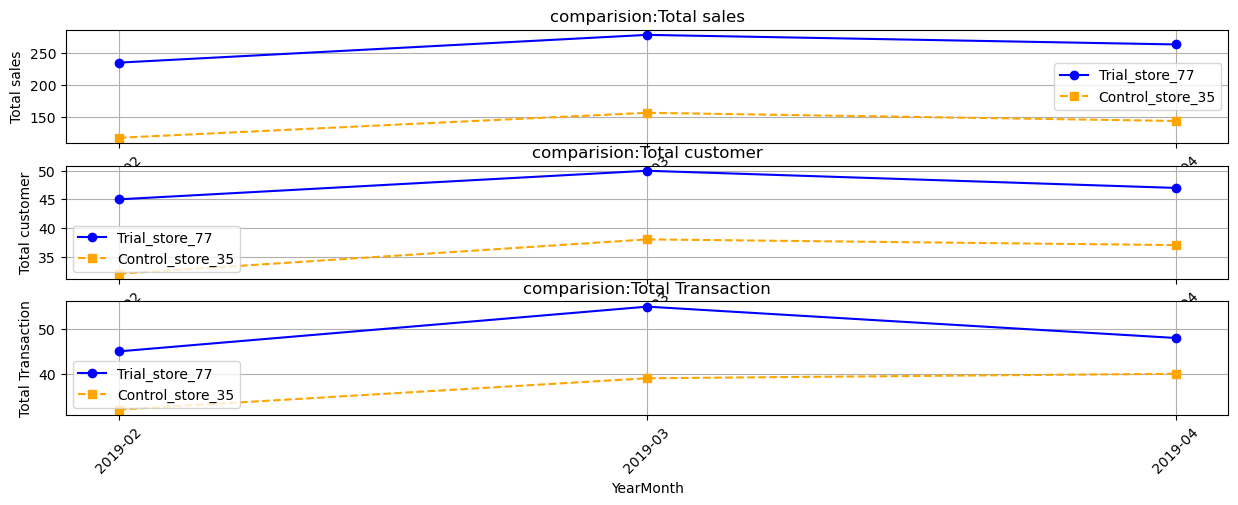

In [26]:
Trial_store_77_df=store_77[Trial_store_77]
Control_store_35_df=store_35[Trial_store_35]
#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(Trial_store_77_df["YearMonth"], Trial_store_77_df["Total_sales"],label="Trial_store_77",marker="o",color="blue")
plt.plot(Control_store_35_df["YearMonth"],Control_store_35_df["Total_sales"],label="Control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(Trial_store_77_df["YearMonth"],Trial_store_77_df["Total_customer"],label="Trial_store_77",marker="o",color="blue")
plt.plot(Control_store_35_df["YearMonth"],Control_store_35_df["Total_customer"],label="Control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(Trial_store_77_df["YearMonth"],Trial_store_77_df["Total_Transaction"],label="Trial_store_77",marker="o",color="blue")
plt.plot(Control_store_35_df["YearMonth"],Control_store_35_df["Total_Transaction"],label="Control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [28]:
store_86=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==86]
store_231=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==231]

In [29]:
store_86=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==86]
store_231=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==231]
#Percentage increase in the total sales comparing the Trial sales with the control store

#calculating the pretrial and Trial period for both trial and control store
PreTrial_store_86=(store_86["YearMonth"]>="2018-07")&(store_86["YearMonth"]<="2019-01")
Trial_store_86=(store_86["YearMonth"]>="2019-02")&(store_86["YearMonth"]<="2019-04")

PreTrial_store_231=(store_231["YearMonth"]>="2018-07")&(store_231["YearMonth"]<="2019-01")
Trial_store_231=(store_231["YearMonth"]>="2019-02")&(store_231["YearMonth"]<="2019-04")

#calculating total sales for pretrial and trial period for both Trial and control store
PreTrial_store_86_Totalsales=store_86.loc[PreTrial_store_86,"Total_sales"].sum()
PreTrial_store_231_Totalsales=store_231.loc[PreTrial_store_231,"Total_sales"].sum()
scaling_factor=PreTrial_store_86_Totalsales/PreTrial_store_231_Totalsales

Trial_store_86_Totalsales=store_86.loc[Trial_store_86,"Total_sales"].sum()
Trial_store_231_Totalsales=store_231.loc[Trial_store_231,"Total_sales"].sum()

#finding the scaling factor of the trial and the control store as they don't necessary have thesame output
scaled_trial_231=Trial_store_231_Totalsales*scaling_factor
percentage_lift=((Trial_store_86_Totalsales-scaled_trial_231)/scaled_trial_231)*100

print(f"percentage_change_Totalsales:{percentage_lift:.2f}%")

#Percentage increase in the total customers comparing the Trial sales with the control store
PreTrial_store_86_Customer=store_86.loc[PreTrial_store_86,"Total_customer"].sum()
PreTrial_store_231_Customer=store_231.loc[PreTrial_store_231,"Total_customer"].sum()
scaling_factor=PreTrial_store_86_Customer/PreTrial_store_231_Customer

Trial_store_86_Customer=store_86.loc[Trial_store_86,"Total_customer"].sum()
Trial_store_231_Customer=store_231.loc[Trial_store_231,"Total_customer"].sum()

scaled_trial_231=Trial_store_231_Customer*scaling_factor
percentage_lift=((Trial_store_86_Customer-scaled_trial_231)/scaled_trial_231)*100

print(f"percentage_change_customer:{percentage_lift:.2f}%")

#percentage incraese in the total transaction comparing the Trial sales with the control store
PreTrial_store_86_Transaction=store_86.loc[PreTrial_store_86,"Total_Transaction"].sum()
PreTrial_store_231_Transaction=store_231.loc[PreTrial_store_231,"Total_Transaction"].sum()
scaling_factor=PreTrial_store_86_Transaction/PreTrial_store_231_Transaction

Trial_store_86_Transaction=store_86.loc[Trial_store_86,"Total_Transaction"].sum()
Trial_store_231_Transaction=store_231.loc[Trial_store_231,"Total_Transaction"].sum()

scaled_trial_231=Trial_store_231_Transaction*scaling_factor
percentage_lift=((Trial_store_86_Transaction-scaled_trial_231)/scaled_trial_231)*100

print(f"percentage_change_TotalTransaction:{percentage_lift:.2f}%")

percentage_change_Totalsales:5.67%
percentage_change_customer:12.45%
percentage_change_TotalTransaction:7.90%


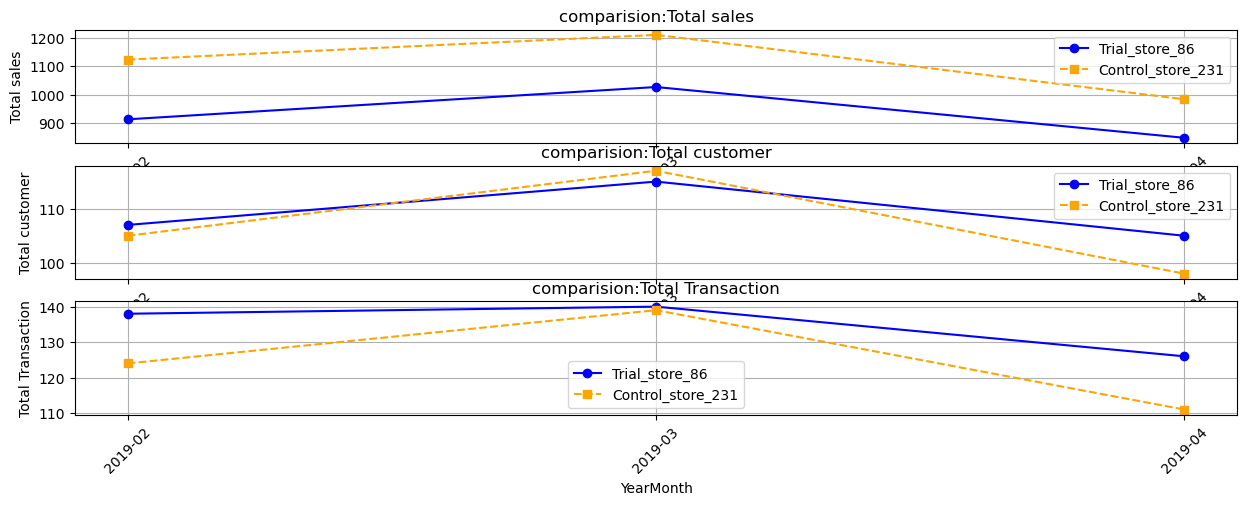

In [30]:
Trial_store_86_df=store_86[Trial_store_86]
Control_store_231_df=store_231[Trial_store_231]
#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(Trial_store_86_df["YearMonth"], Trial_store_86_df["Total_sales"],label="Trial_store_86",marker="o",color="blue")
plt.plot(Control_store_231_df["YearMonth"],Control_store_231_df["Total_sales"],label="Control_store_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(Trial_store_86_df["YearMonth"],Trial_store_86_df["Total_customer"],label="Trial_store_86",marker="o",color="blue")
plt.plot(Control_store_231_df["YearMonth"],Control_store_231_df["Total_customer"],label="Control_store_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(Trial_store_86_df["YearMonth"],Trial_store_86_df["Total_Transaction"],label="Trial_store_86",marker="o",color="blue")
plt.plot(Control_store_231_df["YearMonth"],Control_store_231_df["Total_Transaction"],label="Control_store_231",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [31]:
store_88=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==88]
store_229=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==229]

In [32]:
#Percentage increase in the total sales comparing the Trial sales with the control store
store_88=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==88]
store_229=Monthly_metrics_for_Trial_stores[Monthly_metrics_for_Trial_stores['STORE_NBR']==229]
#calculating the pretrial and Trial period for both trial and control store
PreTrial_store_88=(store_88["YearMonth"]>="2018-07")&(store_88["YearMonth"]<="2019-01")
Trial_store_88=(store_88["YearMonth"]>="2019-02")&(store_88["YearMonth"]<="2019-04")

PreTrial_store_229=(store_229["YearMonth"]>="2018-07")&(store_229["YearMonth"]<="2019-01")
Trial_store_229=(store_229["YearMonth"]>="2019-02")&(store_229["YearMonth"]<="2019-04")

#calculating total sales for pretrial and trial period for both Trial and control store
PreTrial_store_88_Totalsales=store_88.loc[PreTrial_store_88,"Total_sales"].sum()
PreTrial_store_229_Totalsales=store_229.loc[PreTrial_store_229,"Total_sales"].sum()
scaling_factor=PreTrial_store_88_Totalsales/PreTrial_store_229_Totalsales

Trial_store_88_Totalsales=store_88.loc[Trial_store_88,"Total_sales"].sum()
Trial_store_229_Totalsales=store_229.loc[Trial_store_229,"Total_sales"].sum()

#finding the scaling factor of the trial and the control store as they don't necessary have thesame output
scaled_trial_229=Trial_store_229_Totalsales*scaling_factor
percentage_lift=((Trial_store_88_Totalsales-scaled_trial_229)/scaled_trial_229)*100

print(f"percentage_change_Totalsales:{percentage_lift:.2f}%")

#Percentage increase in the total customers comparing the Trial sales with the control store
PreTrial_store_88_Customer=store_88.loc[PreTrial_store_88,"Total_customer"].sum()
PreTrial_store_229_Customer=store_229.loc[PreTrial_store_229,"Total_customer"].sum()
scaling_factor=PreTrial_store_88_Customer/PreTrial_store_229_Customer

Trial_store_88_Customer=store_88.loc[Trial_store_88,"Total_customer"].sum()
Trial_store_229_Customer=store_229.loc[Trial_store_229,"Total_customer"].sum()

scaled_trial_229=Trial_store_229_Customer*scaling_factor
percentage_lift=((Trial_store_88_Customer-scaled_trial_229)/scaled_trial_229)*100

print(f"percentage_change_customer:{percentage_lift:.2f}%")

#percentage incraese in the total transaction comparing the Trial sales with the control store
PreTrial_store_88_Transaction=store_88.loc[PreTrial_store_88,"Total_Transaction"].sum()
PreTrial_store_229_Transaction=store_229.loc[PreTrial_store_229,"Total_Transaction"].sum()
scaling_factor=PreTrial_store_88_Transaction/PreTrial_store_229_Transaction

Trial_store_88_Transaction=store_88.loc[Trial_store_88,"Total_Transaction"].sum()
Trial_store_229_Transaction=store_229.loc[Trial_store_229,"Total_Transaction"].sum()

scaled_trial_229=Trial_store_229_Transaction*scaling_factor
percentage_lift=((Trial_store_88_Transaction-scaled_trial_229)/scaled_trial_229)*100

print(f"percentage_change_TotalTransaction:{percentage_lift:.2f}%")

percentage_change_Totalsales:-2.03%
percentage_change_customer:-5.55%
percentage_change_TotalTransaction:-1.34%


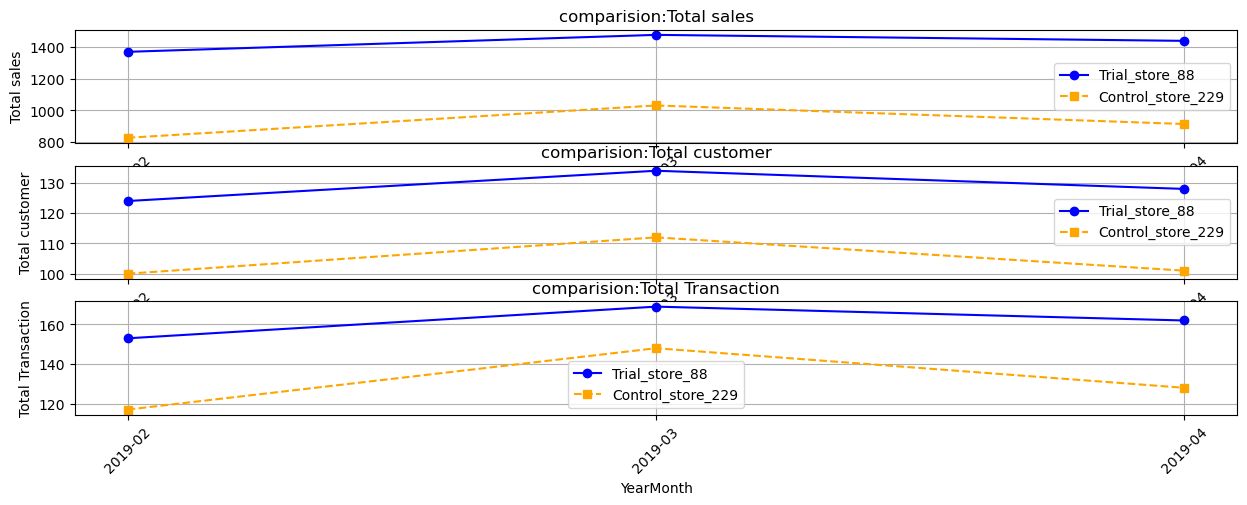

In [33]:
Trial_store_88_df=store_88[Trial_store_88]
Control_store_229_df=store_229[Trial_store_229]
#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(Trial_store_88_df["YearMonth"],Trial_store_88_df["Total_sales"],label="Trial_store_88",marker="o",color="blue")
plt.plot(Control_store_229_df["YearMonth"],Control_store_229_df["Total_sales"],label="Control_store_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(Trial_store_88_df["YearMonth"],Trial_store_88_df["Total_customer"],label="Trial_store_88",marker="o",color="blue")
plt.plot(Control_store_229_df["YearMonth"],Control_store_229_df["Total_customer"],label="Control_store_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(Trial_store_88_df["YearMonth"],Trial_store_88_df["Total_Transaction"],label="Trial_store_88",marker="o",color="blue")
plt.plot(Control_store_229_df["YearMonth"],Control_store_229_df["Total_Transaction"],label="Control_store_229",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(store_77["YearMonth"],store_77["Total_sales"])
plt.xlabel("YearMonth")
plt.ylabel("Total_sales")
plt.title("YearMonthly sales for Trial store 77")
plt.grid()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(store_77["YearMonth"],store_77["Total_customer"])
plt.xlabel("YearMonth")
plt.ylabel("Total_customer")
plt.title("YearMonthly customer for Trial store 77")
plt.grid()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(store_77["YearMonth"],store_77["Total_Transaction"])
plt.xlabel("YearMonth")
plt.ylabel("Total_Transaction")
plt.title("YearMonthly Transation for Trial store 77")
plt.grid()
plt.show()

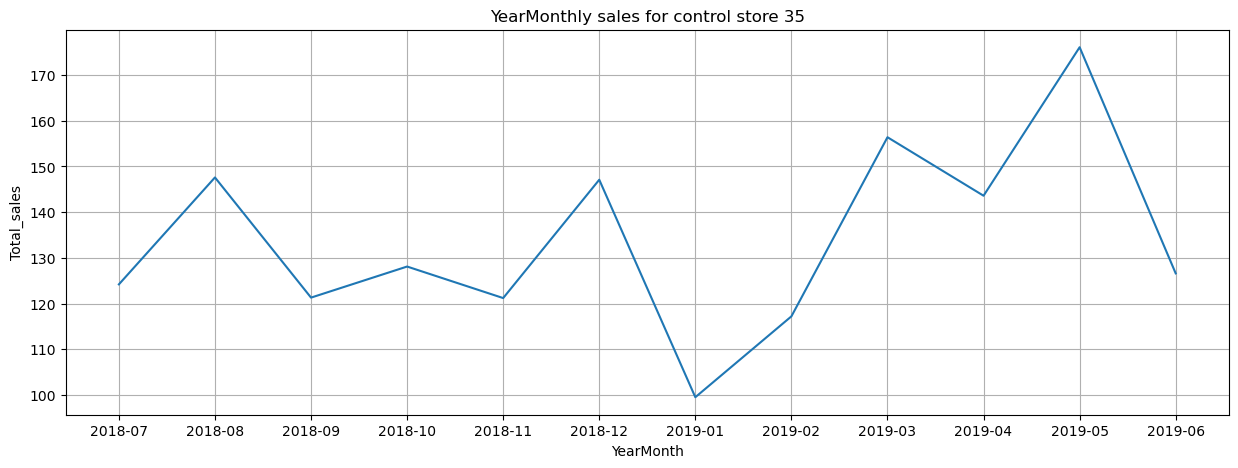

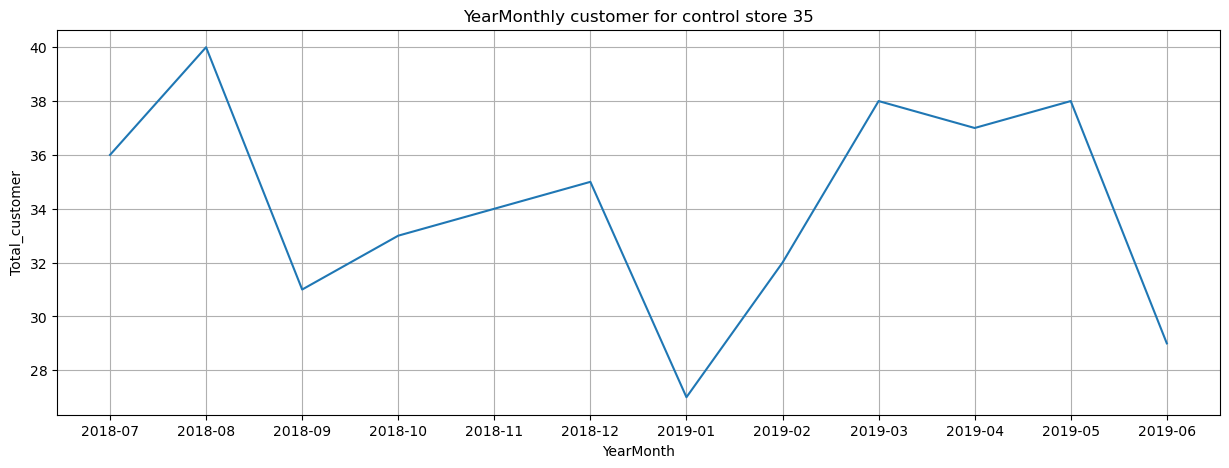

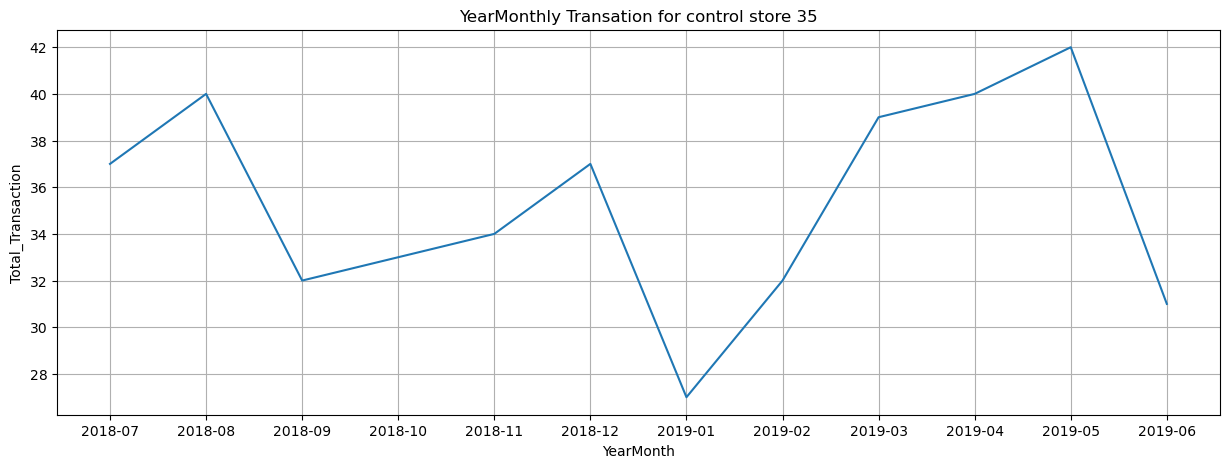

In [78]:
plt.figure(figsize=(15,5))
plt.plot(store_35["YearMonth"],store_35["Total_sales"])
plt.xlabel("YearMonth")
plt.ylabel("Total_sales")
plt.title("YearMonthly sales for control store 35")
plt.grid()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(store_35["YearMonth"],store_35["Total_customer"])
plt.xlabel("YearMonth")
plt.ylabel("Total_customer")
plt.title("YearMonthly customer for control store 35")
plt.grid()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(store_35["YearMonth"],store_35["Total_Transaction"])
plt.xlabel("YearMonth")
plt.ylabel("Total_Transaction")
plt.title("YearMonthly Transation for control store 35")
plt.grid()
plt.show()




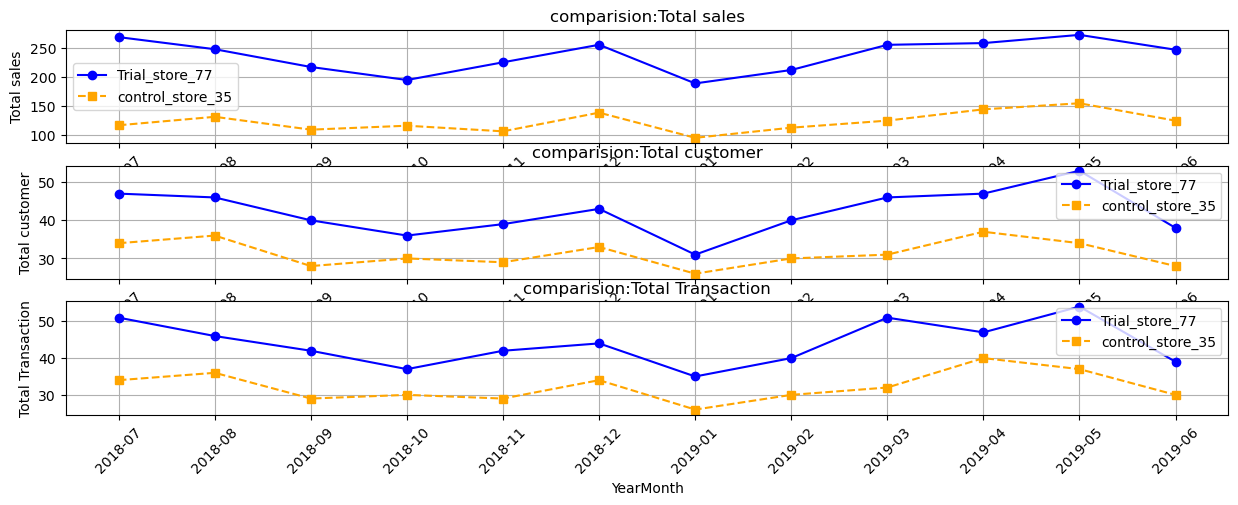

In [95]:
Trial_store_77=Monthly_metrics[Monthly_metrics["Store_nbr"]==77]
control_store_35=Monthly_metrics[Monthly_metrics["Store_nbr"]==35]

#Setting the width and the height
plt.figure(figsize=(15,5))

#Graph one:Total sales
plt.subplot(3,1,1)
plt.plot(Trial_store_77["YearMonth"],Trial_store_77["Total_sales"],label="Trial_store_77",marker="o",color="blue")
plt.plot(control_store_35["YearMonth"],control_store_35["Total_sales"],label="control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total sales")
plt.ylabel("Total sales")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph two:Total customers
plt.subplot(3,1,2)
plt.plot(Trial_store_77["YearMonth"],Trial_store_77["Total_customers"],label="Trial_store_77",marker="o",color="blue")
plt.plot(control_store_35["YearMonth"],control_store_35["Total_customers"],label="control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total customer")
plt.ylabel("Total customer")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

#Graph three:Total sales
plt.subplot(3,1,3)
plt.plot(Trial_store_77["YearMonth"],Trial_store_77["Total_Transactions"],label="Trial_store_77",marker="o",color="blue")
plt.plot(control_store_35["YearMonth"],control_store_35["Total_Transactions"],label="control_store_35",marker="s",color="orange",linestyle="--")
plt.title("comparision:Total Transaction")
plt.ylabel("Total Transaction")
plt.xlabel("YearMonth")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)


plt.show()